In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
class BoxMuller:
    def __init__(self, mu,cov):
        self.mu = np.reshape(mu,(-1,1))
        self.cov = cov
        self.L = np.linalg.cholesky(cov)
        self.d = np.shape(mu)[0] # Dimension of RV
        
    def generate(self):
        while True:
            # Generate two independent uniform rv
            # z = 2*np.random.uniform(0,1,size=(self.d,1))-1
            z = np.random.uniform(-1,1,size=(self.d,1))
            s = np.linalg.norm(z,ord=2)

            if s < 1:
                k = np.sqrt(-2*np.log(s)/s)
                u = z*k
                u = self.mu + self.L @ u
                return u
    def generate_samples(self, n=100):
        samples = []
        for i in range(n):
            samples.append(self.generate())
        return np.array(samples).reshape(-1,self.d)

In [74]:
bm = BoxMuller(np.array([0,0]),np.diag([5,1]))

In [75]:
samples = bm.generate_samples()

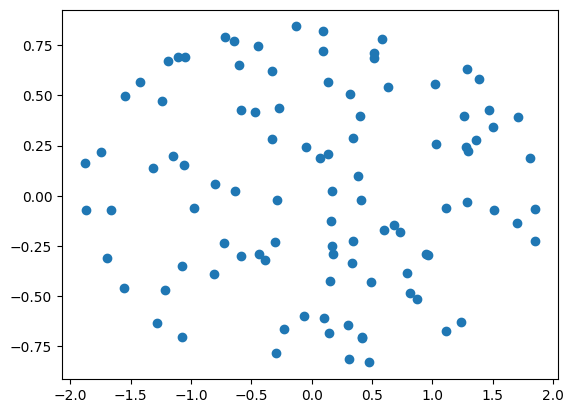

In [76]:
plt.scatter(samples[:,0],samples[:,1])